# Planning Multiple Experiments with Pyomo.DoE

Multi-experiment design is useful when several experiments can be run in parallel. Instead of designing one experiment at a time, we optimize multiple experiments together so that they provide complementary information about the model parameters. In Pyomo.DoE, this is done by maximizing a scalar function of the sum of the Fisher information matrices from each experiment, together with any prior information.

Maximize a scalar-valued function $\psi(\cdot)$ of the sum of the Fisher information matrices $\mathbf{M}$:
$$
\begin{align*}
\max_{u_1,.., u_{N_{exp}}} \quad & \psi \left(\sum_{k\in E}\mathbf{M}_k(u_k) + \mathbf{M}_0\right) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_{H,k}}{dt} = U_a (T_{amb, k} - T_{H, k}) + U_b (T_{S,k} - T_{H,k}) + \alpha P u_k(t); \; \forall k \in E\\
& C_p^S \frac{dT_{S, k}}{dt} = U_b (T_{H,k} - T_{S,k}); \; \forall k \in E \\
& 0\% \leq u_k(t) \leq 100 \%; \; \forall k \in E\\
& T_{H,k}(t_0) = T_{amb, k}; \; \forall k \in E\\
& T_{S, k}(t_0) = T_{amb, k}; \; \forall k \in E
\end{align*}
$$
Here, $E=\{1, 2, ..., N_{exp}\}$ is the set of experiments in the experimental campaign.
`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for 
- $\psi(\cdot) = \log_{10}(\mathrm{trace (FIM)})$, i.e., Pseudo A-optimality 
- $\psi(\cdot) = \log_{10}(\mathrm{trace (FIM^{-1})})$, i.e., A-optimality, and 
- $\psi(\cdot) = \log_{10}(\mathrm{det (FIM)})$, i.e., D-optimality.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


## Use prior parameter information
We will use the parameter estimates and covariance matrix obtained in the previous notebook. Since the Fisher information matrix (FIM) is the inverse of the covariance matrix, we can use that result as prior information for the new design problem.

In [3]:
import numpy as np
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.environ import SolverFactory

# Theta values estimated from the regularized regresssion in the previous notebook
# L2 regularization
theta_values = {
    'Ua': 0.041705,
    'Ub': 0.016071,
    'inv_CpH': 0.170038,
    'inv_CpS': 3.344923,
}

# Cov estimated from the regularized regression in the previous notebook
# L2 regularization
# cov = np.array([[1.866383e-10, -6.533734e-11, 1.660092e-09, -6.218168e-08],
#                 [-6.533734e-11, 2.344163e-05, 1.542480e-05, -5.182207e-03],
#                 [1.660092e-09, 1.542480e-05, 1.021121e-05, -3.412824e-03],
#                 [-6.218168e-08, -5.182207e-03, -3.412824e-03, 1.145830e+00]])
# FIM = np.linalg.inv(cov)
FIM = np.array([[ 4.10787913e+05, 5.83103844e+03, -7.72857515e+03, -4.64962204e+05],
                [ 5.83103844e+03, 3.60598526e+02, -1.01751947e+03, -9.72220827e+03],
                [-7.72857515e+03, -1.01751947e+03, 4.59244578e+03, 2.04302015e+04],
                [-4.64962204e+05, -9.72220827e+03, 2.04302015e+04, 5.62847749e+05]])
results_summary(FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 5.990600199348212
A-optimality: 4.6922343900838
D-optimality: 8.358655244656996
E-optimality: -4.692234827961623
Modified E-optimality: 10.673840088261834

FIM:
 [[ 4.10787913e+05  5.83103844e+03 -7.72857515e+03 -4.64962204e+05]
 [ 5.83103844e+03  3.60598526e+02 -1.01751947e+03 -9.72220827e+03]
 [-7.72857515e+03 -1.01751947e+03  4.59244578e+03  2.04302015e+04]
 [-4.64962204e+05 -9.72220827e+03  2.04302015e+04  5.62847749e+05]]

eigenvalues:
 [9.58529963e+05 1.94558594e+04 6.02883651e+02 2.03125839e-05]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.6472    0.6888   -0.3027    0.1226
Ub         0.0117   -0.1036    0.1850    0.9772
inv_CpH   -0.0216    0.4341    0.8922   -0.1226
inv_CpS   -0.7619    0.5712   -0.2795    0.1226


As in the [sequential design notebook](./doe_optimize_pseudo_A.ipynb), we will scale the parameters before solving the design problem because their nominal values differ substantially in magnitude. This improves numerical conditioning in `DesignOfExperiments`.

## Initialize two experiments
We now create two experiment objects. The first uses the measured sine-test data, and the second uses a different initial input profile so that the optimizer can refine both experiments jointly.

In [4]:
from dataclasses import replace
# Create a new experiemnt object for design of experiments, using the same data and 
# theta values as before
# Here, we will induce a step size of 6 seconds, as to make the optimization problem 
# more tractable 

skip = 6

# Create the data object considering the new control points every 60 seconds
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


# Set a random seed for reproducibility
SEED: int = 11 # Choose any integer seed you like
PDF = "normal" # Choose between "normal" or "uniform" distribution for the new design of u1


def get_initial_u1_design(PDF="uniform", seed=11, sample_data = tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the 
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)    
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design 
    # is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new


tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


## Optimize two experiments (D-optimality)
We now create a DesignOfExperiments object for the two experiments and choose a D-optimality objective. We also pass prior_FIM, which represents information already available from previous parameter estimation.

In [5]:
from pyomo.contrib.doe.utils import rescale_FIM
theta_ref = np.array([
    theta_values["Ua"],
    theta_values["Ub"],
    theta_values["inv_CpH"],
    theta_values["inv_CpS"],
])
# Because the parameter values differ substantially in magnitude, we can use parameter 
# scaling in DesignOfExperiments to improve numerical conditioning.
RESCALE_FIM = True # Set to True if you want to rescale the FIM, False otherwise
FIM_scaled = FIM
# if RESCALE_FIM:
#     FIM_scaled = rescale_FIM(FIM, theta_ref)
# else:
#     FIM_scaled = FIM

# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  
    # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=RESCALE_FIM,
    objective_option="determinant",  
    # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM_scaled,  
    tee=True,
    solver=solver,
    # use_grey_box_objective=True,
    grey_box_tee = True,

)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

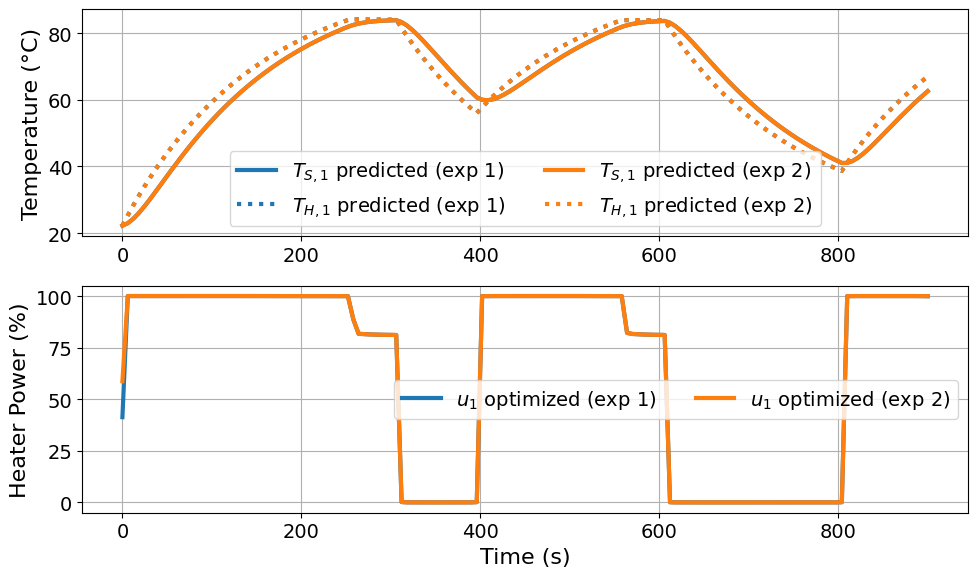

In [6]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

In [7]:
FIM_D = np.asarray(TC_Lab_DoE_D.results["solution"]["param_scenarios"][0]['total_fim'])
if RESCALE_FIM:
    D = np.diag(theta_ref)
    FIM_unscaled_D = D @ FIM_D @ D
else:
    FIM_unscaled_D = FIM_D
results_summary(np.asarray(FIM_unscaled_D))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 6.8574556860508045
A-optimality: -0.8449421526281435
D-optimality: 16.26360396116109
E-optimality: 0.8452838811555438
Modified E-optimality: 6.009687315010861

FIM:
 [[ 1.39390613e+04  3.40504649e+01 -3.44951677e+03 -6.28662246e+04]
 [ 3.40504649e+01  1.56470635e+01  4.90121250e+02  3.09291686e+03]
 [-3.44951677e+03  4.90121250e+02  3.05624982e+04  1.43257672e+05]
 [-6.28662246e+04  3.09291686e+03  1.43257672e+05  7.15752540e+06]]

eigenvalues:
 [7.16095915e+06 2.80168696e+04 1.30595819e+04 7.00299605e+00]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.0088    0.1477   -0.9890   -0.0072
Ub        -0.0004   -0.0148   -0.0095    0.9998
inv_CpH   -0.0201   -0.9887   -0.1477   -0.0160
inv_CpS   -0.9998    0.0212   -0.0057   -0.0002


Now, we will compare different FIM metrics before and after the experimental design. 

In [8]:
# Create a helper function to compute FIM metrics
def log10_FIM_metric(FIM):
    pseudo_A_opt = np.log10(np.trace(FIM))
    A_opt = np.log10(np.trace(np.linalg.inv(FIM)))
    D_opt = np.log10(np.linalg.det(FIM))
    E_opt = np.log10(np.min(np.linalg.eigvals(FIM)))
    ME_opt = np.log10(np.max(np.linalg.eigvals(FIM)) / np.min(np.linalg.eigvals(FIM)))
    return pseudo_A_opt, A_opt, D_opt, E_opt, ME_opt


In [9]:
import pandas as pd
prior_metrics = log10_FIM_metric(FIM)
optimized_metrics = log10_FIM_metric(FIM_unscaled_D)
metric_names = ["pseudo_A_opt", "A_opt", "D_opt", "E_opt", "ME_opt"]

metrics_df = pd.DataFrame(
    {
        "prior": list(prior_metrics),
        "optimized": list(optimized_metrics),
    },
    index=metric_names,
)
metrics_df.index.name = "metric"

metrics_df.round(2)

,prior,optimized
metric,,
pseudo_A_opt,5.99,6.86
A_opt,4.69,-0.84
D_opt,8.36,16.26
E_opt,-4.69,0.85
ME_opt,10.67,6.01


## Activity: Repeat the design with A-optimality
In this activity, we repeat the same workflow as above but change only the design objective. The repeated setup is shown again here so the section can be run independently.

In [10]:
# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="trace",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM_scaled,  # We use the prior information from the existing experiment!
    tee=True,
    solver=solver,
    # use_grey_box_objective=True,
    grey_box_tee = True,

)

TC_Lab_DoE_A.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

### Analyze the results

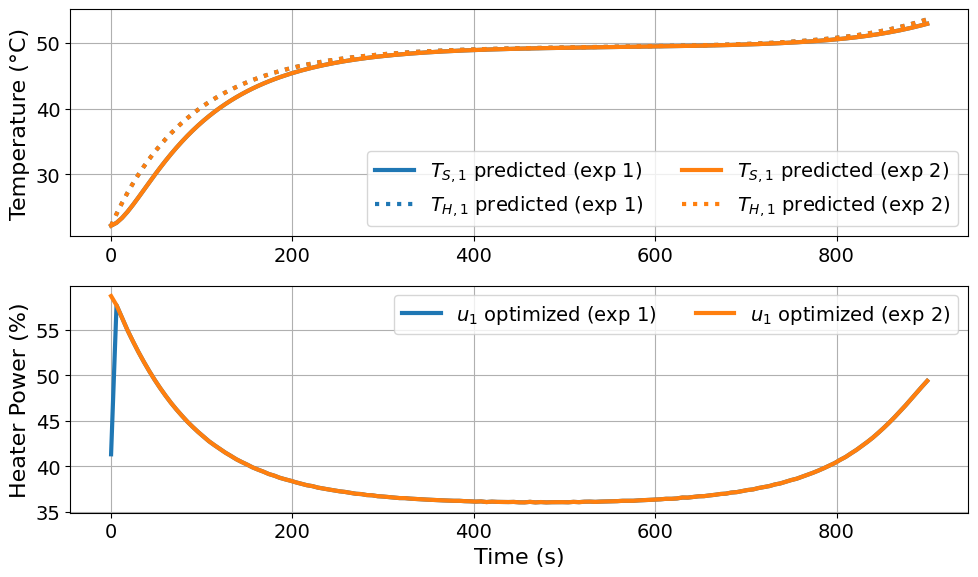

In [11]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_A)

Convert the scaled FIM to unscaled FIM so that the comparison is fair.

In [12]:
FIM_A = np.asarray(TC_Lab_DoE_A.results["solution"]["param_scenarios"][0]['total_fim'])
D = np.diag(theta_ref)
FIM_unscaled_A = D @ FIM_A @ D
results_summary(np.asarray(FIM_unscaled_A))

FIM_A = np.asarray(TC_Lab_DoE_A.results["solution"]["param_scenarios"][0]['total_fim'])
if RESCALE_FIM:
    D = np.diag(theta_ref)
    FIM_unscaled_A = D @ FIM_A @ D
else:
    FIM_unscaled_A = FIM_A
results_summary(np.asarray(FIM_unscaled_A))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 6.80583976432115
A-optimality: 0.2414280614070656
D-optimality: 13.70974801757347
E-optimality: -0.24127745056597508
Modified E-optimality: 7.04654265710549

FIM:
 [[ 4.61457437e+03 -1.48074174e+01 -2.25867541e+03 -7.10682264e+04]
 [-1.48074174e+01  1.46570471e+00  6.21744636e+01 -1.78851643e+02]
 [-2.25867541e+03  6.21744636e+01  4.76848667e+03  2.96880025e+04]
 [-7.10682264e+04 -1.78851643e+02  2.96880025e+04  6.38560392e+06]]

eigenvalues:
 [6.38653368e+06 6.19692642e+03 2.25727214e+03 5.73749803e-01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.0111    0.6304   -0.7762    0.0031
Ub        -0.0000   -0.0096   -0.0118   -0.9999
inv_CpH    0.0047   -0.7762   -0.6303    0.0149
inv_CpS    0.9999    0.0106   -0.0057   -0.0001
======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 6.80583976432115
A-optimality: 0.2414280614070656
D-optima

In [13]:
cov_A = np.linalg.inv(FIM_unscaled_A)
print("Standard Deviations from Design A:")
for param, std in zip(theta_values.keys(), np.sqrt(np.diag(cov_A))):
    print(f"{param}: {std:.2e}")

Standard Deviations from Design A:
Ua: 1.87e-02
Ub: 1.32e+00
inv_CpH: 2.57e-02
inv_CpS: 4.43e-04


**Discussion**: How does changing the `objective` change the result? Which one is better for reducing the uncertainty in our experiment?